<a href="https://colab.research.google.com/github/efugal18-afk/IS-4487/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 10 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data
3. Fit a model
4. Test the accuracy of the model
6.  Use the model to predict on a new dataset (without the target)

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary


| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| customer_id | Unique customer identifier | Numeric | |
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |

### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [74]:
#Import libraries  🔧
import sklearn as sk
import pandas as pd
import matplotlib.pyplot as plt

## Step 1: Initial Data Understanding

### Do the following:
 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the DataSets folder and look for `adviseinvest_historical_data.csv`)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [37]:
df = pd.read_csv('/content/adviseinvest_historical_data (1).csv')
display(df.head())

,customer_id,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,10098,0,-65600,0,24,2,1,0,1,1.0,1,1,3,0,0
1,184,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
2,194,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0
3,689,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
4,811,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0


In [38]:
#View the datatypes 🔧
df.dtypes

,0
customer_id,int64
answered,int64
income,int64
female,object
age,int64
job,int64
num_dependents,int64
rent,int64
own_res,int64
new_car,float64


In [39]:
#Describe the data 🔧
df.describe()

,customer_id,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,14850.475563,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,8517.254310,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,99.000000,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7474.750000,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,14850.500000,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,22226.250000,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,29602.000000,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


## Step 2: Data Preparation

### 2.1: Data Cleanup
- Check for and remove any outliers
- Consider fixing any missing data (should you delete the record or impute the value?)
- Clean up the data and put it in a new dataframe named "df_clean"


In [40]:
# Remove outliers with negative income
df_clean = df[df['income'] >= 0]

df_clean = df_clean[df_clean['age'] <= 100]

num_accts_threshold = df_clean['num_accts'].quantile(0.99)
df_clean = df_clean[df_clean['num_accts'] <= num_accts_threshold]

print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_clean.shape}")
display(df_clean.head())

Original DataFrame shape: (29504, 15)
Cleaned DataFrame shape: (29499, 15)


,customer_id,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
1,184,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
2,194,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0
3,689,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
4,811,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0
5,811,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0


In [41]:
# Check for missing values
missing_values = df_clean.isnull().sum()
print("Missing values before imputation:\n", missing_values[missing_values > 0])
if 'new_car' in df_clean.columns and df_clean['new_car'].isnull().any():
    mode_new_car = df_clean['new_car'].mode()[0]
    df_clean['new_car'] = df_clean['new_car'].fillna(mode_new_car)
    print(f"\nMissing values in 'new_car' imputed with mode: {mode_new_car}")

print("\nMissing values after imputation:\n", df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values before imputation:
 new_car    2
dtype: int64

Missing values in 'new_car' imputed with mode: 0.0

Missing values after imputation:
 Series([], dtype: int64)


### 2.2: Standardize variables

 - Change "answered" to a boolean (true/false) type
 - Convert any variables that should be an integer into an integer

In [42]:
# Convert answered to boolean
df_clean['answered'] = df_clean['answered'].astype(bool)
display(df_clean.head())

,customer_id,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
1,184,False,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
2,194,False,4330,0,22,2,1,1,0,0.0,3,0,0,0,0
3,689,False,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
4,811,False,4330,0,22,2,1,1,0,0.0,3,0,0,0,0
5,811,False,4330,0,22,2,1,1,0,0.0,3,0,0,0,0


In [43]:
# Convert 'new_car' to integer type, as it contains binary values (0 or 1)
df_clean['new_car'] = df_clean['new_car'].astype(int)

# Display the data types to verify the change
print("Data types after converting 'new_car' to integer:")
display(df_clean.dtypes)

Data types after converting 'new_car' to integer:


,0
customer_id,int64
answered,bool
income,int64
female,object
age,int64
job,int64
num_dependents,int64
rent,int64
own_res,int64
new_car,int64


### 2.3 Convert variables to categorical

- Find at least 8 variables that would be appropriate to convert to categories

In [44]:
categorical_cols_to_convert = ['female', 'job', 'num_dependents', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'mobile', 'product']

for col in categorical_cols_to_convert:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

print("Data types after converting to category:")
display(df_clean.dtypes)

Data types after converting to category:


,0
customer_id,int64
answered,bool
income,int64
female,category
age,int64
job,category
num_dependents,category
rent,category
own_res,category
new_car,category


# Step 3: Exploratory Data Analysis (EDA)

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted



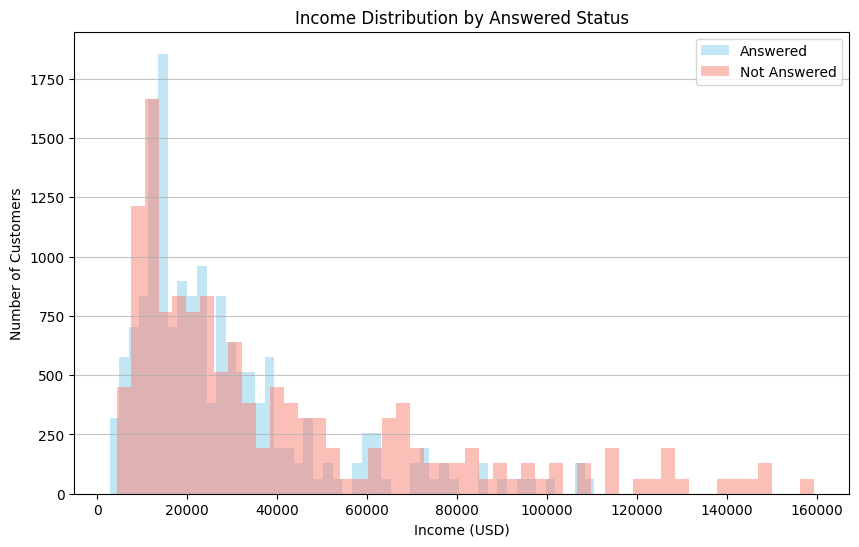

In [47]:
# Chart 1 🔧
plt.figure(figsize=(10, 6))
plt.hist(df_answered['income'], bins=50, alpha=0.5, label='Answered', color='skyblue')
plt.hist(df_not_answered['income'], bins=50, alpha=0.5, label='Not Answered', color='salmon')
plt.title('Income Distribution by Answered Status')
plt.xlabel('Income (USD)')
plt.ylabel('Number of Customers')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Text(0.5, 1.0, 'Female Customers: Answered vs. Not Answered')

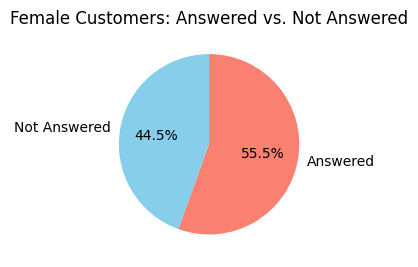

In [54]:
# Chart 2 🔧
# Pie chart for Females (female=0)
plt.subplot(1, 2, 1)
female_data = gender_answered_counts.loc[0]
plt.pie(female_data, labels=female_data.index.map({True: 'Answered', False: 'Not Answered'}), autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Female Customers: Answered vs. Not Answered')

/tmp/ipykernel_527/3845921249.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dependents_answered_counts = df_clean.groupby(['num_dependents', 'answered']).size().unstack(fill_value=0)


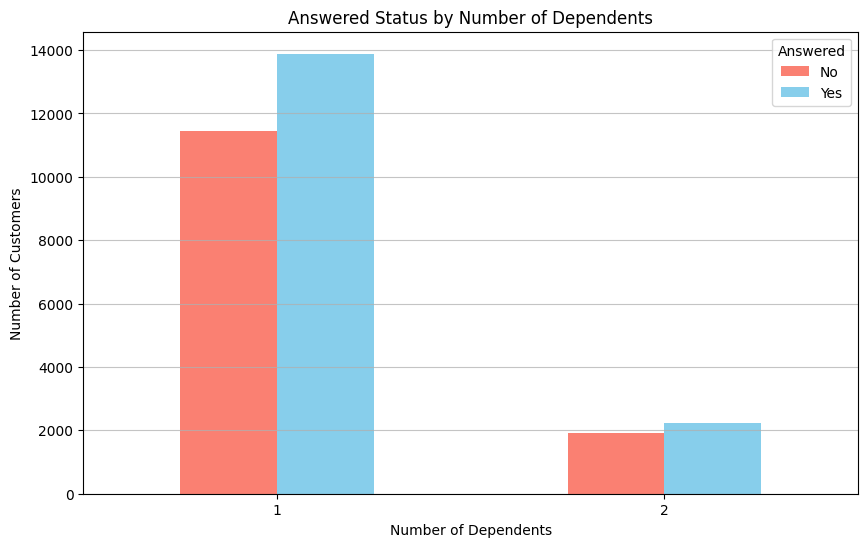

In [55]:
# Chart 3 🔧
import seaborn as sns

dependents_answered_counts = df_clean.groupby(['num_dependents', 'answered']).size().unstack(fill_value=0)

dependents_answered_counts.plot(kind='bar', figsize=(10, 6), color=['salmon', 'skyblue'])
plt.title('Answered Status by Number of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Answered', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.75)
plt.show()

/tmp/ipykernel_527/3298068629.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  new_car_answered_counts = df_clean.groupby(['new_car', 'answered']).size().unstack(fill_value=0)


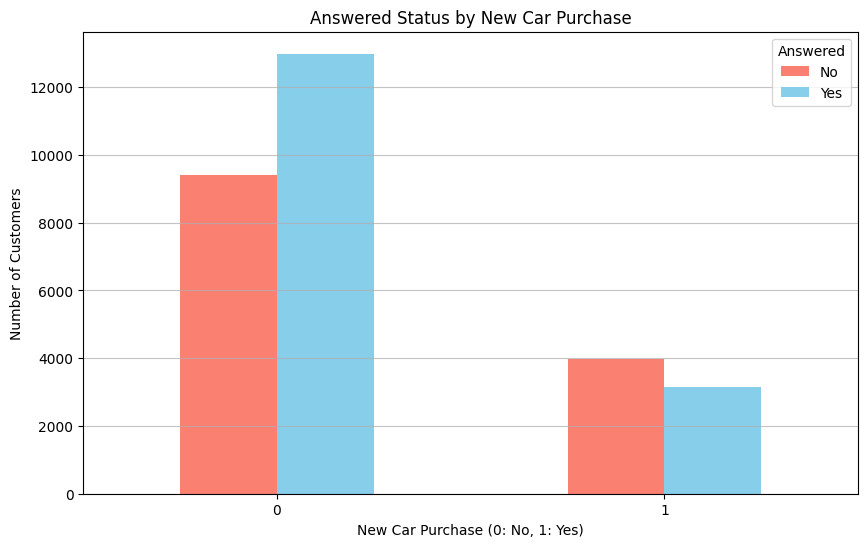

In [56]:
# Chart 4 🔧

new_car_answered_counts = df_clean.groupby(['new_car', 'answered']).size().unstack(fill_value=0)

new_car_answered_counts.plot(kind='bar', figsize=(10, 6), color=['salmon', 'skyblue'])
plt.title('Answered Status by New Car Purchase')
plt.xlabel('New Car Purchase (0: No, 1: Yes)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Answered', labels=['No', 'Yes'])
plt.grid(axis='y', alpha=0.75)
plt.show()

/tmp/ipykernel_527/1112157370.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='answered', y='income', data=df_clean, palette={'True': 'skyblue', 'False': 'salmon'})


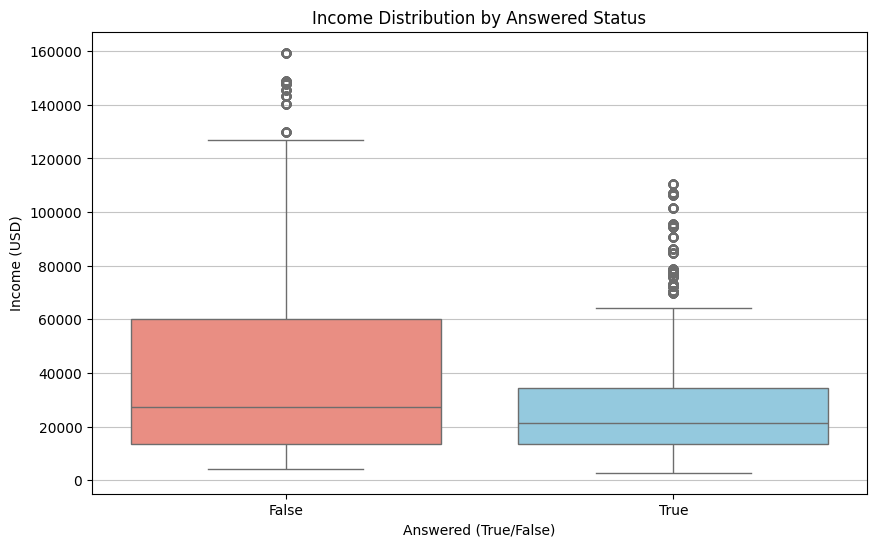

In [58]:
# Chart 5 🔧
plt.figure(figsize=(10, 6))
sns.boxplot(x='answered', y='income', data=df_clean, palette={'True': 'skyblue', 'False': 'salmon'})
plt.title('Income Distribution by Answered Status')
plt.xlabel('Answered (True/False)')
plt.ylabel('Income (USD)')
plt.xticks(ticks=[0, 1], labels=['False', 'True'])
plt.grid(axis='y', alpha=0.75)
plt.show()

## Step 4: Modeling

### 4.1: Calculate the base probability of answering

If we use no model at all, how good is our chance of predicting someone leaving?  Use a calculation to find the chances of someone leaving.

In [59]:
#get the default probability 🔧
base_probability_answered = df_clean['answered'].value_counts(normalize=True).get(True, 0)
print(f"Base probability of a customer answering: {base_probability_answered:.2f}")

Base probability of a customer answering: 0.55


### 4.2: Split the training and testing datasets

- split df_clean using train_test_split function
- all variables except answered should be in the x variable
- answered is in the y variable


In [73]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('answered', axis=1)
y = df_clean['answered']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (23599, 14)
X_test shape: (5900, 14)
y_train shape: (23599,)
y_test shape: (5900,)


### 4.3: Create a Decision Tree
- Use all available attributes (except those that were eliminated in step 3)
- It is recommended to use the type "entropy" and a max_depth of 4

In [143]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Exclude 'customer_id' explicitly from the features used for training the model
features_to_exclude = ['income', 'female', 'num_dependents', 'new_car', 'product', 'customer_id']
X_filtered = df_clean.drop(columns=['answered'] + features_to_exclude, axis=1)
y_filtered = df_clean['answered']

X_train_filtered, X_test_filtered, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

categorical_cols = X_train_filtered.select_dtypes(include='category').columns.tolist()
numerical_cols = X_train_filtered.select_dtypes(exclude='category').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # 'remainder' handles columns not explicitly processed, typically numerical ones that are not in categorical_cols
)

dtree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42))
])

dtree_pipeline.fit(X_train_filtered, y_train)

print("Decision Tree Classifier created and fitted successfully with max_depth=4 and excluded appropriate variables (including product and customer_id)!")


Decision Tree Classifier created and fitted successfully with max_depth=4 and excluded appropriate variables (including product and customer_id)!


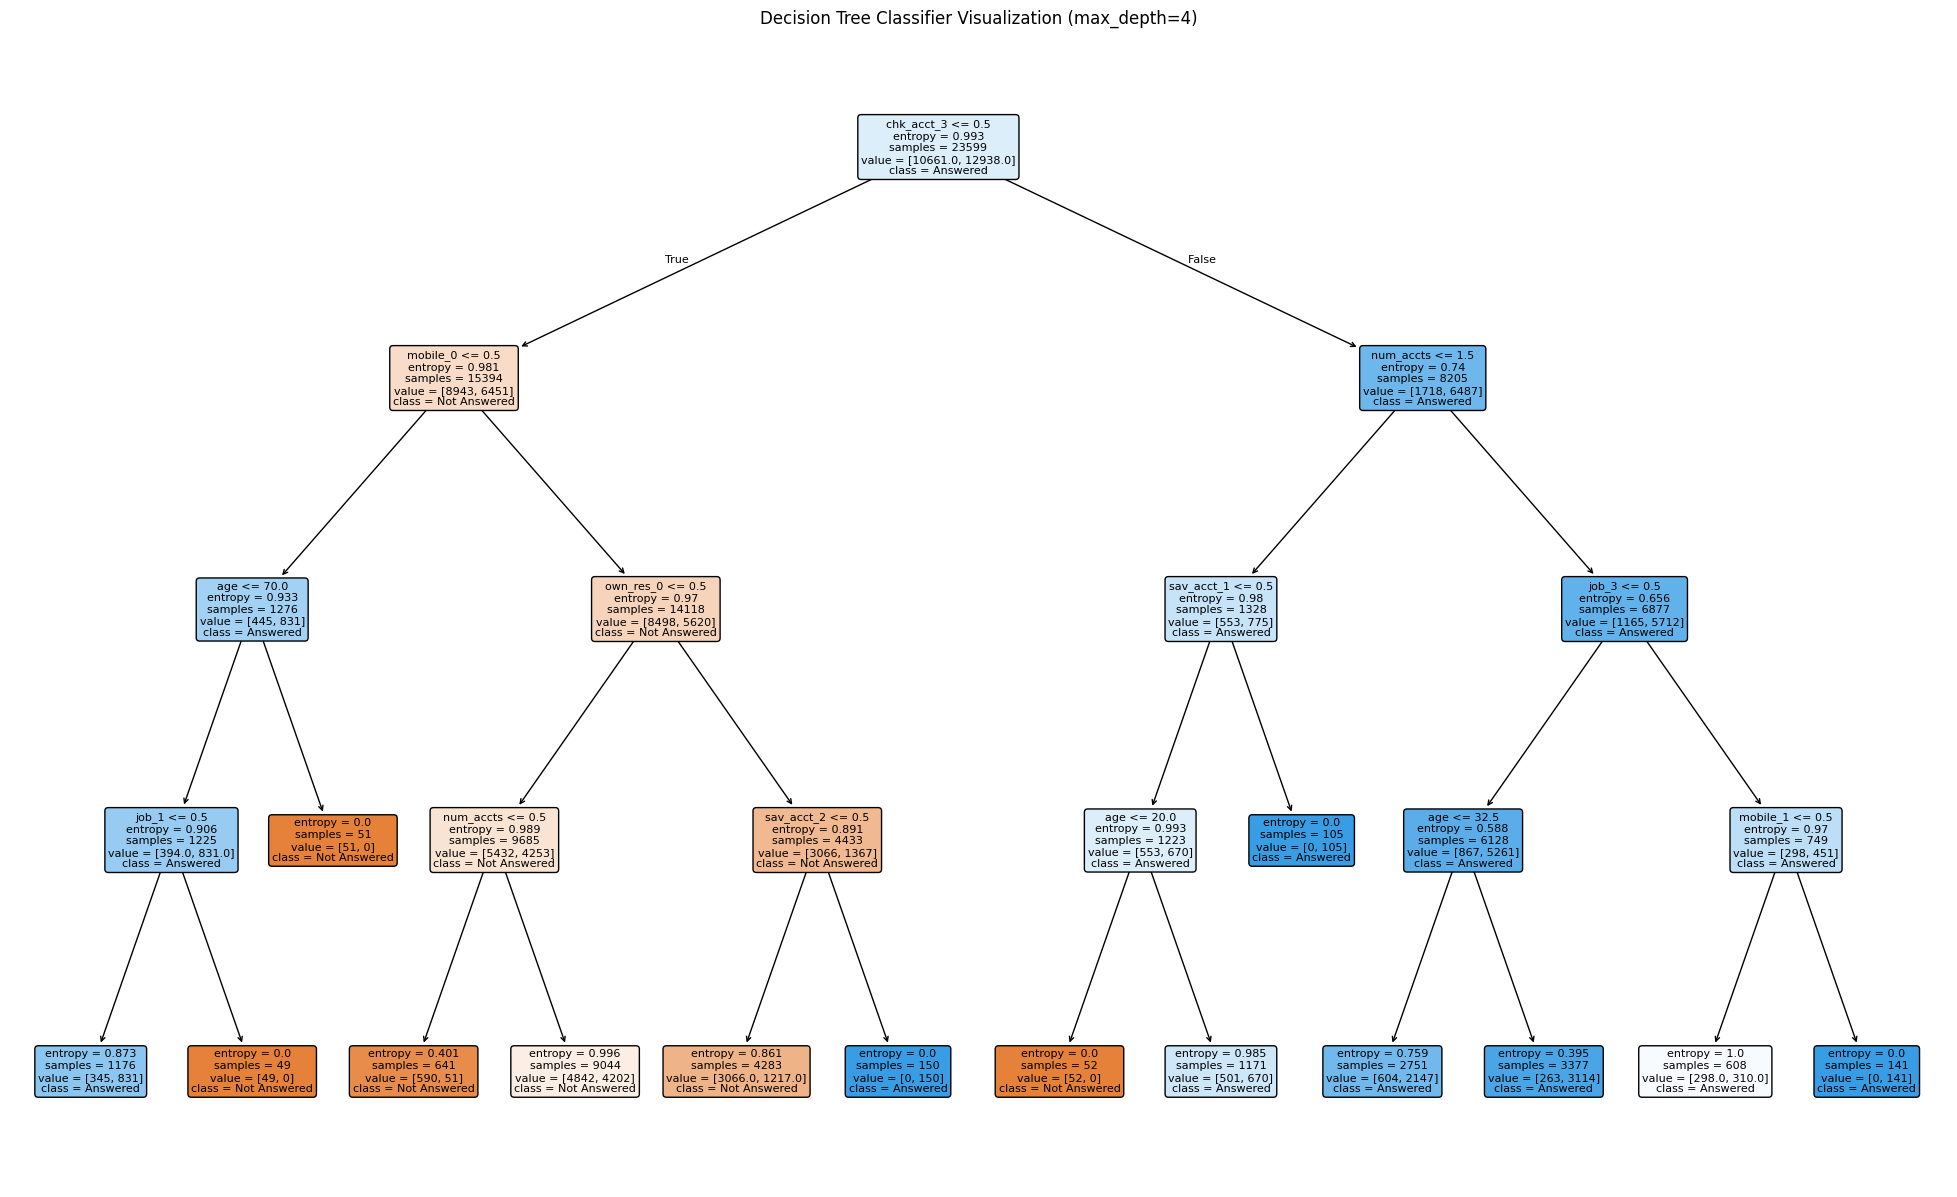

In [130]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

onehot_encoder = dtree_pipeline.named_steps['preprocessor'].named_transformers_['cat']
categorical_feature_names = onehot_encoder.get_feature_names_out(categorical_cols)
numerical_cols_remaining = numerical_cols
all_feature_names = numerical_cols_remaining + list(categorical_feature_names)
dtree_classifier = dtree_pipeline.named_steps['classifier']
plt.figure(figsize=(25, 15))
plot_tree(dtree_classifier,
          filled=True,
          rounded=True,
          class_names=['Not Answered', 'Answered'],
          feature_names=all_feature_names,
          fontsize=8)
plt.title('Decision Tree Classifier Visualization (max_depth=4)')
plt.show()

### 4.4: What is the accuracy?

This should be better than the base probability, or you have failed in your objective

In [131]:
from sklearn.metrics import accuracy_score
y_pred = dtree_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the Decision Tree Classifier: {accuracy:.2f}")

Accuracy of the Decision Tree Classifier: 0.68


### 4.5: Create a confusion matrix

This will show false positives, true positives, etc.

In [132]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2164  549]
 [1314 1873]]


Create a more visual, interpretable version of the matrix

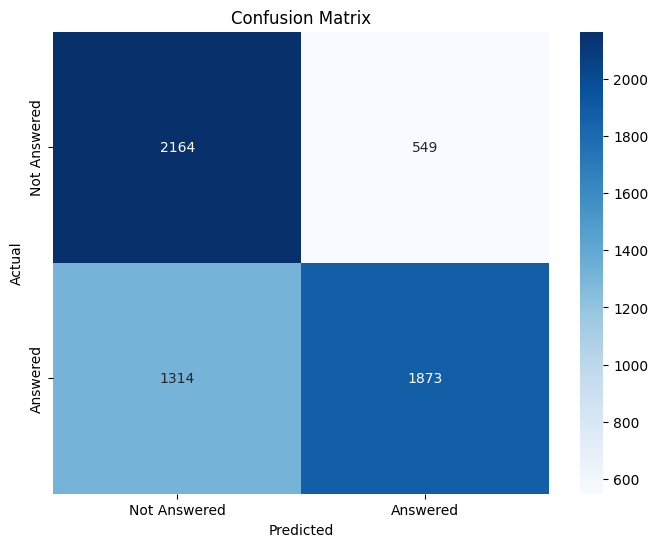

In [133]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Answered', 'Answered'],
            yticklabels=['Not Answered', 'Answered'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Step 5: Evaluate the Model

**Assumptions**

One of the simplifying assumptions we will make in this project is that all the customers who answer the phone will purchase a product. (This assumption is actually verified by the data.) To model "answered" in this case is therefore equivalent to modeling "purchased."

There are costs and benefits in this case. We will assume that customers purchase a product for 100 dollars. This was the average cost of AdviseInvest products, according to the Director of Sales.  Also, as we learned in the interview, the agent time to make the sale is worth 25 dollars. Profit would therefore be \$75 dollars for an answered call and a purchase. In sum:

**Benefit**: True positive. The customer is predicted to answer, does answer, and purchases a product for 100 dollars for a profit of 100 - 25 = 75.

**Cost**: False positive. The customer is predicted to answer, but does not answer, so there is a loss of 25. (We assume the agent cannot schedule another call at the last minute, or spends the entire time slot trying to make the call.)

When you create a calculation you can use:
- True answered * 75 -> These people purchased
- False answered * 25 -> You can't schedule another call

For this exercise, we propose that customers who are not predicted to answer will not be called, so there would be no benefits and no costs for them.  

### 5.1 Calculate the Profit Using the Model

In [134]:
cm_model = confusion_matrix(y_test, y_pred)
true_positives = cm_model[1, 1]
false_positives = cm_model[0, 1]
profit_per_tp = 75
cost_per_fp = 25
model_profit = (true_positives * profit_per_tp) - (false_positives * cost_per_fp)

print(f"Number of True Positives: {true_positives}")
print(f"Number of False Positives: {false_positives}")
print(f"Profit using the model: ${model_profit}")

Number of True Positives: 1873
Number of False Positives: 549
Profit using the model: $126750


### 5.2 Compare to the Default Profit

How much profit (revenue - costs) could be expected if all customers are called? We can consider this a baseline case for profit since it does not require a model.

In other words, to calculate profit in this baseline scenario treat the customers who answer as true positives treat the customers who do not answer as false positives.

In [135]:
total_answered_customers = df_clean['answered'].sum()
total_not_answered_customers = len(df_clean) - total_answered_customers
baseline_profit = (total_answered_customers * profit_per_tp) - (total_not_answered_customers * cost_per_fp)

print(f"Total customers who actually answered: {total_answered_customers}")
print(f"Total customers who actually did not answer: {total_not_answered_customers}")
print(f"Baseline profit (if all customers are called): ${baseline_profit}")

Total customers who actually answered: 16125
Total customers who actually did not answer: 13374
Baseline profit (if all customers are called): $875025


### 5.3 Tune the Model
- Adjust the size or shape of the tree, then test the accuracy
- Keep changing these parameters until you end up with a tree with accuracy that is better than the initial model

In [153]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

dtree_pipeline_complex = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(criterion='entropy', max_depth=8, random_state=42))
])

dtree_pipeline_complex.fit(X_train_filtered, y_train)

print("Decision Tree Classifier with increased complexity (max_depth=8) created and fitted successfully!")


Decision Tree Classifier with increased complexity (max_depth=8) created and fitted successfully!


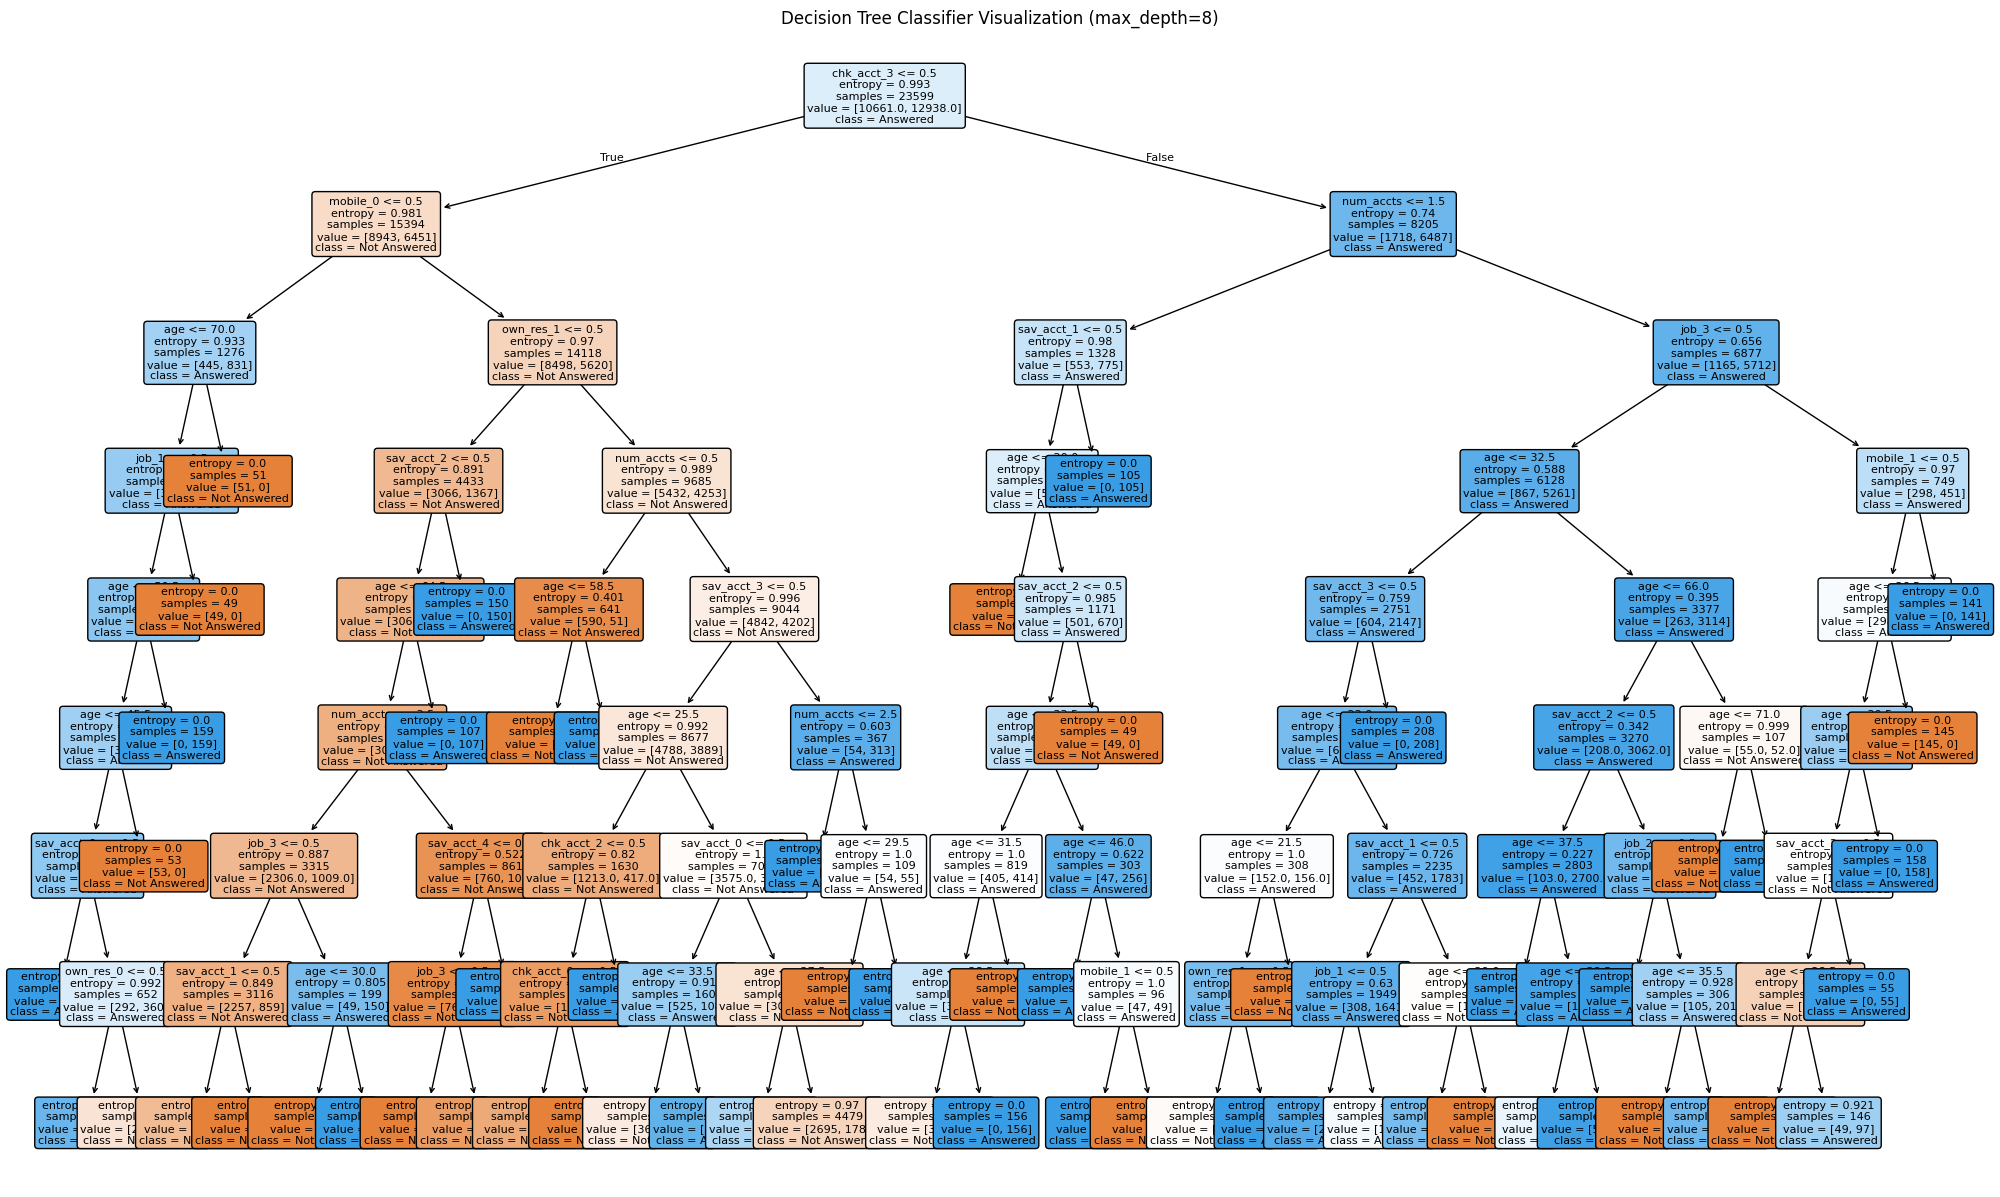

In [146]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
dtree_classifier_complex = dtree_pipeline_complex.named_steps['classifier']

plt.figure(figsize=(25, 15))
plot_tree(dtree_classifier_complex,
          filled=True,
          rounded=True,
          class_names=['Not Answered', 'Answered'],
          feature_names=all_feature_names,
          fontsize=8)
plt.title('Decision Tree Classifier Visualization (max_depth=8)')
plt.show()

In [147]:
from sklearn.metrics import accuracy_score
y_pred_complex = dtree_pipeline_complex.predict(X_test_filtered)
accuracy_complex = accuracy_score(y_test, y_pred_complex)

print(f"Accuracy of the more complex Decision Tree Classifier (max_depth=8): {accuracy_complex:.2f}")

Accuracy of the more complex Decision Tree Classifier (max_depth=8): 0.80


### 5.4 Apply the Model to New Customers
- Import the "adviseinvest_new_customer_data.csv" file
- Using the tree model, predict each customer for the target variable  by feeding the new customer data into the model

In [148]:
#Import new customer data into a new data frame 🔧
df_new_customers = pd.read_csv('/content/adviseinvest_new_customer_data.csv')
display(df_new_customers.head())

,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,customer_id
0,30010,0,40,2,1,1,0,0,1,0,3,0,H1597
1,30510,0,54,2,1,0,1,0,0,0,2,0,P1446
2,12880,0,48,2,2,0,1,0,0,1,4,0,E1492
3,15530,0,44,2,1,0,1,0,0,0,2,0,W5143
4,46230,0,40,3,1,0,1,0,3,1,2,0,W4927


In [149]:
df_new_customers_processed = df_new_customers.copy()
cols_to_convert_and_keep_as_cat = ['job', 'rent', 'own_res', 'chk_acct', 'sav_acct', 'mobile']

for col in cols_to_convert_and_keep_as_cat:
    if col in df_new_customers_processed.columns:
        df_new_customers_processed[col] = df_new_customers_processed[col].astype('category')
features_to_drop_from_new_data = ['income', 'female', 'num_dependents', 'new_car', 'product', 'customer_id']

X_new_customers_for_prediction = df_new_customers_processed.drop(
    columns=features_to_drop_from_new_data, errors='ignore'
)


expected_model_input_cols = X_train_filtered.columns.tolist()
missing_cols = [col for col in expected_model_input_cols if col not in X_new_customers_for_prediction.columns]
if missing_cols:

    raise ValueError(f"Missing columns in new customer data for prediction: {missing_cols}")

X_new_customers_for_prediction = X_new_customers_for_prediction[expected_model_input_cols]

new_customer_predictions = dtree_pipeline_complex.predict(X_new_customers_for_prediction)
df_new_customers['predicted_answered'] = new_customer_predictions

print("Predictions for new customers:")
display(df_new_customers.head())


Predictions for new customers:


,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,customer_id,predicted_answered
0,30010,0,40,2,1,1,0,0,1,0,3,0,H1597,False
1,30510,0,54,2,1,0,1,0,0,0,2,0,P1446,False
2,12880,0,48,2,2,0,1,0,0,1,4,0,E1492,True
3,15530,0,44,2,1,0,1,0,0,0,2,0,W5143,False
4,46230,0,40,3,1,0,1,0,3,1,2,0,W4927,False


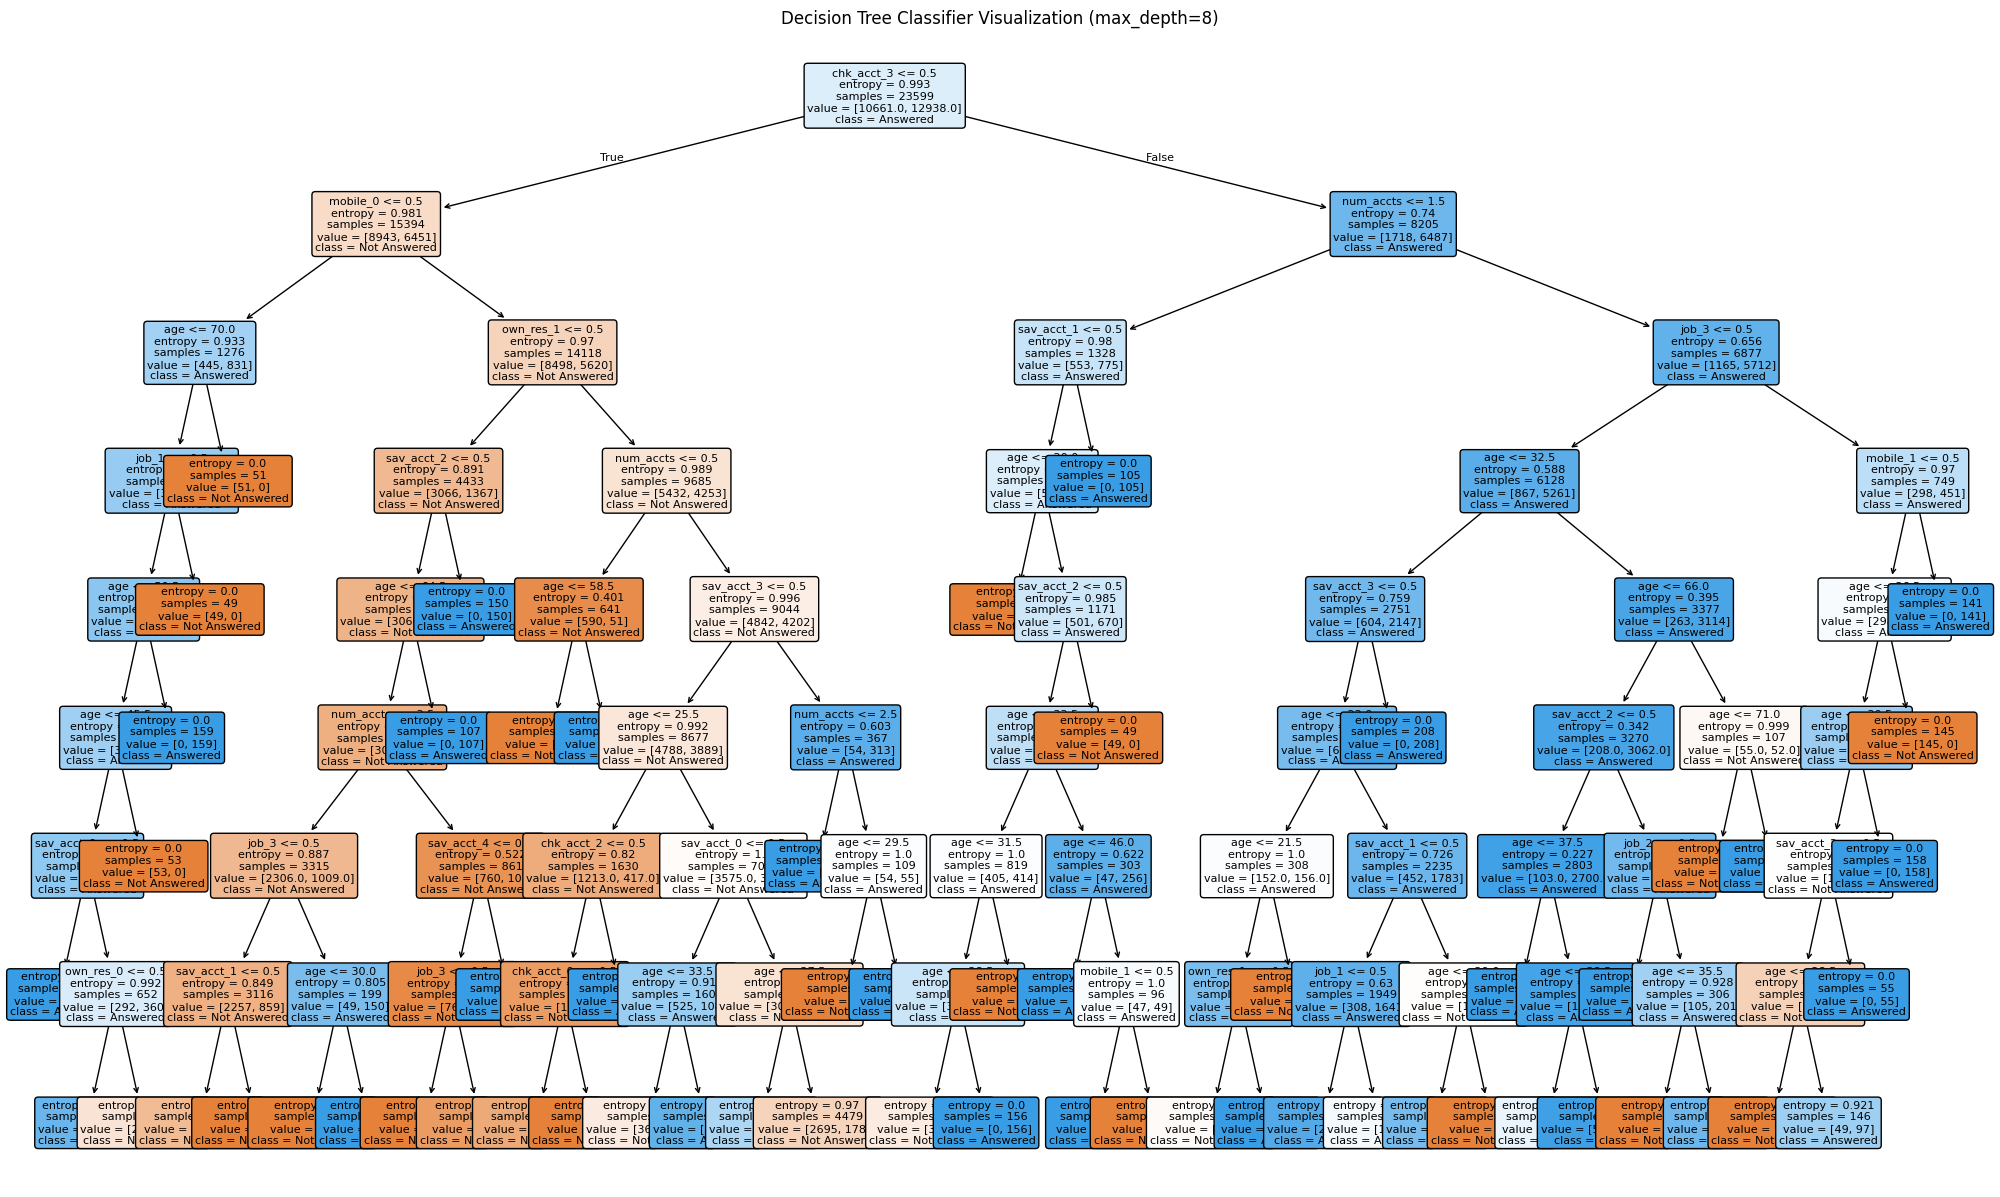

In [150]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dtree_classifier_complex = dtree_pipeline_complex.named_steps['classifier']

plt.figure(figsize=(25, 15))
plot_tree(dtree_classifier_complex,
          filled=True,
          rounded=True,
          class_names=['Not Answered', 'Answered'],
          feature_names=all_feature_names,
          fontsize=8)
plt.title('Decision Tree Classifier Visualization (max_depth=8)')
plt.show()

In [152]:
from sklearn.metrics import confusion_matrix

cm_model_complex = confusion_matrix(y_test, y_pred_complex)
true_positives_complex = cm_model_complex[1, 1]
false_positives_complex = cm_model_complex[0, 1]

model_profit_complex = (true_positives_complex * profit_per_tp) - (false_positives_complex * cost_per_fp)

print(f"Number of True Positives (complex model): {true_positives_complex}")
print(f"Number of False Positives (complex model): {false_positives_complex}")
print(f"Profit using the more complex model: ${model_profit_complex}")

Number of True Positives (complex model): 2274
Number of False Positives (complex model): 291
Profit using the more complex model: $163275


# Step 6: Conclusion
### 6.1: Did we improve our profit using the model?  

Write your conclusion notes below:  🔧
Our estimated profit was higher and closet to the maximum expected using the more complicated model.

### 6.2: How could the model be utilized by the business?

Write your recommendations below:  🔧
This type of model could be very applicable to prescriptive and predictive analytics within a business setting. This is especially where there are many variables that don't seem to have any obvious relationship to the target variable such as in this example.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [154]:
!jupyter nbconvert --to html "assignment_10_FugalEric.ipynb"

[NbConvertApp] Converting notebook assignment_10_FugalEric.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 2598157 bytes to assignment_10_FugalEric.html
